In [15]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn import metrics
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

In [16]:
df=pd.read_csv("d:\python\dataset\diabetes.csv")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\momin\AppData\Local\Temp\ipykernel_8268\3652857805.py:1: SyntaxWarning: invalid escape sequence '\p'
  df=pd.read_csv("d:\python\dataset\diabetes.csv")


In [17]:
df.drop(index=0)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [19]:
feature_cols=["Pregnant","insulin","bmi","age","glucose","bp","pedigree"]
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [20]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=16
)

In [21]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [22]:
cnf_matric=metrics.confusion_matrix(y_test,y_pred)
print(cnf_matric)


[[100  25]
 [ 28  39]]


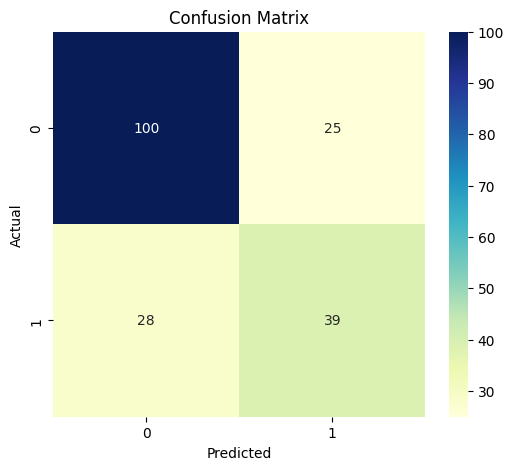

In [23]:
class_names = [0, 1]
plt.figure(figsize=(6,5))
sns.heatmap(cnf_matric, annot=True, fmt='g' ,cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [25]:
target_names = ['No Diabetes', 'Diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

 No Diabetes       0.78      0.80      0.79       125
    Diabetes       0.61      0.58      0.60        67

    accuracy                           0.72       192
   macro avg       0.70      0.69      0.69       192
weighted avg       0.72      0.72      0.72       192



In [26]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7239583333333334


In [27]:
y_prob = clf.predict_proba(X_test)[:, 1] #needs probablities
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)
auc_score = metrics.roc_auc_score(y_test, y_prob) 

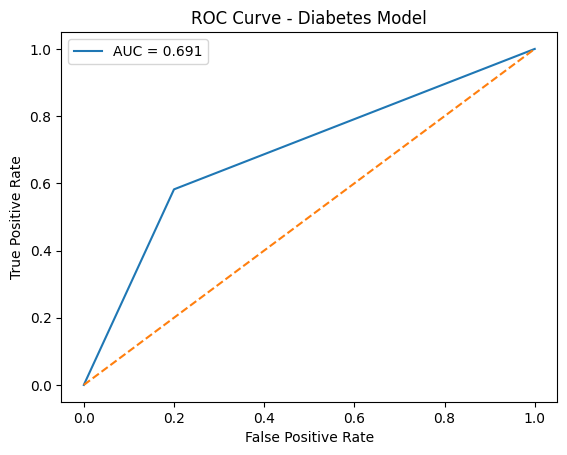

In [28]:
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Model")
plt.legend()

plt.show()

In [29]:
print("Model features:", clf.n_features_in_)
print("Your feature list:", len(feature_cols))

Model features: 8
Your feature list: 7


In [30]:
feature_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"  
]

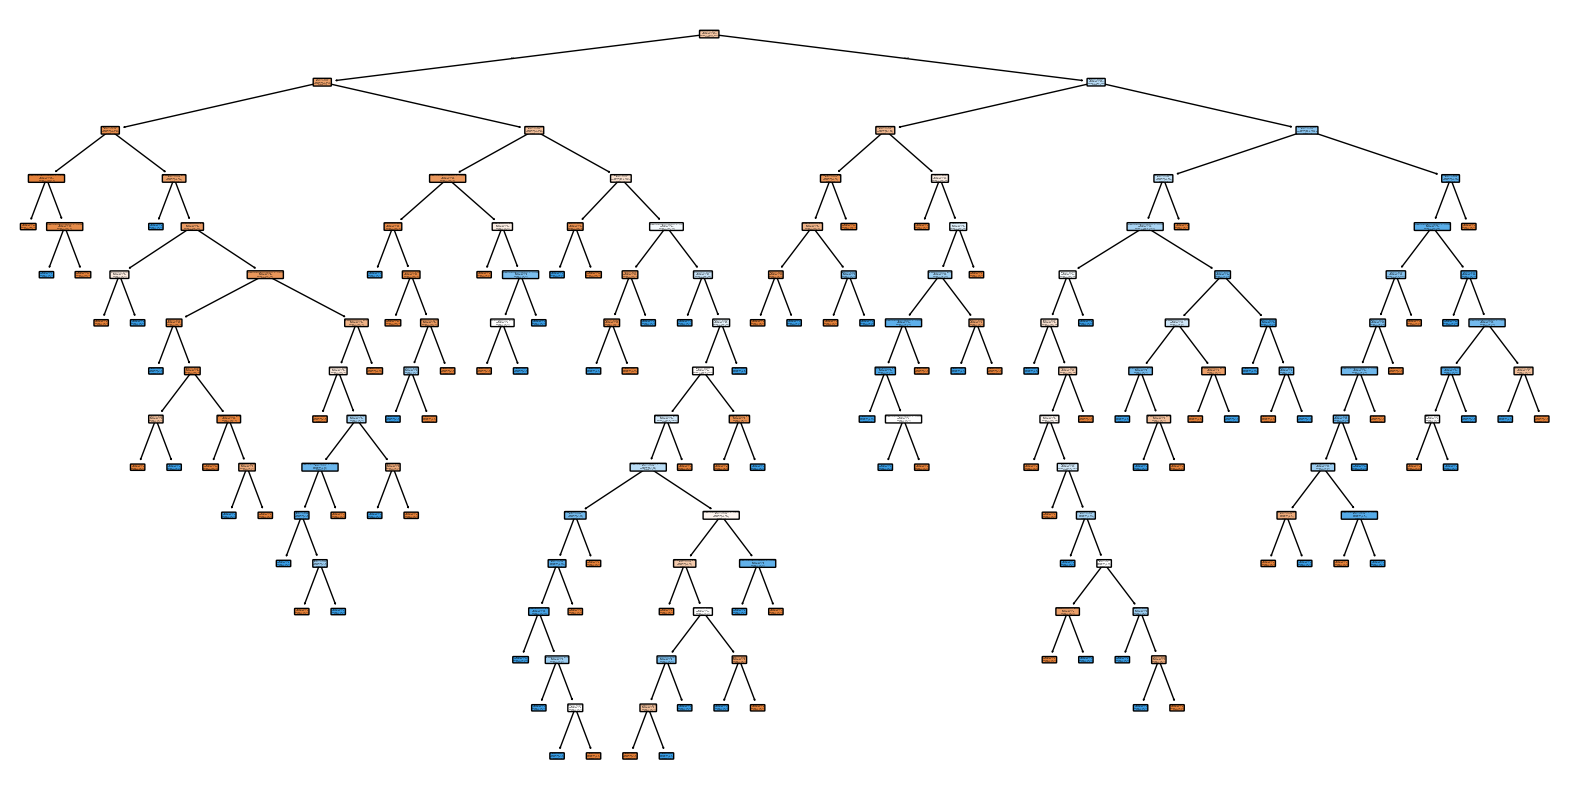

In [31]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=[str(i) for i in clf.classes_],
    filled=True,
    rounded=True
)

plt.show()